In [115]:
from google.colab import files
uploaded = files.upload()

Saving Country-data.csv to Country-data (3).csv
Saving data-dictionary.csv to data-dictionary (4).csv


In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import joblib

plt.style.use("ggplot")

df = pd.read_csv("Country-data.csv")

print(df.shape)
print(df.info())
print(df.head())
print(df.columns)

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0   

In [117]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [118]:
print(df.shape)
print(df.info())
print(df.columns)

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


In [119]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [120]:
df.duplicated().sum()

np.int64(0)

In [121]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [122]:
df["country"].nunique()

167

In [123]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


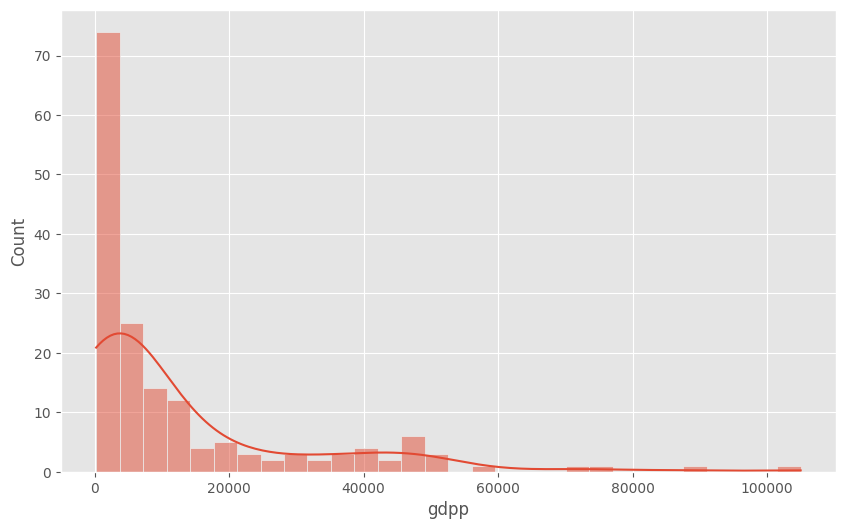

In [124]:
plt.figure(figsize=(10,6))
sns.histplot(df["gdpp"],bins=30,kde=True)
plt.show()

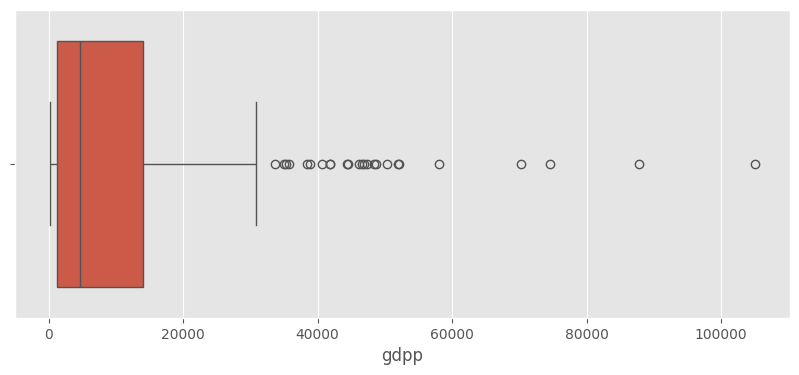

In [125]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["gdpp"])
plt.show()

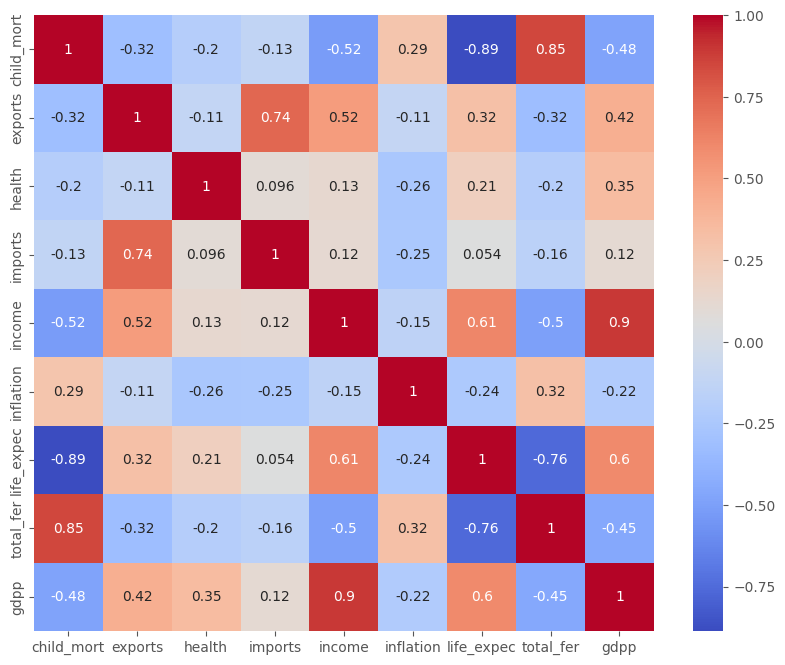

In [126]:
numeric=df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric.corr(),annot=True,cmap="coolwarm")
plt.show()

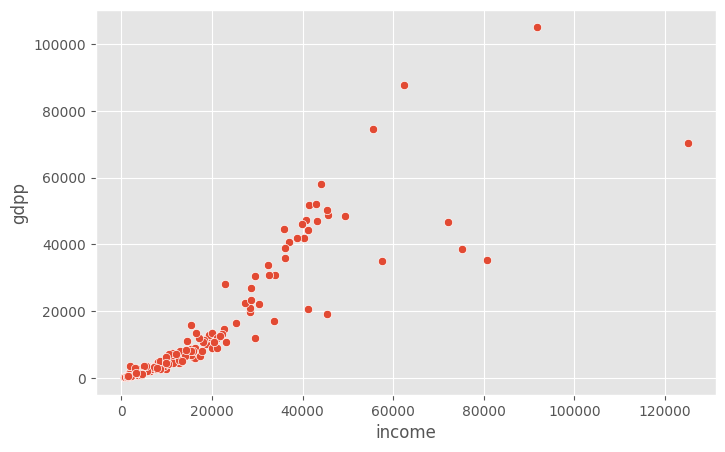

In [127]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="income",y="gdpp")
plt.show()

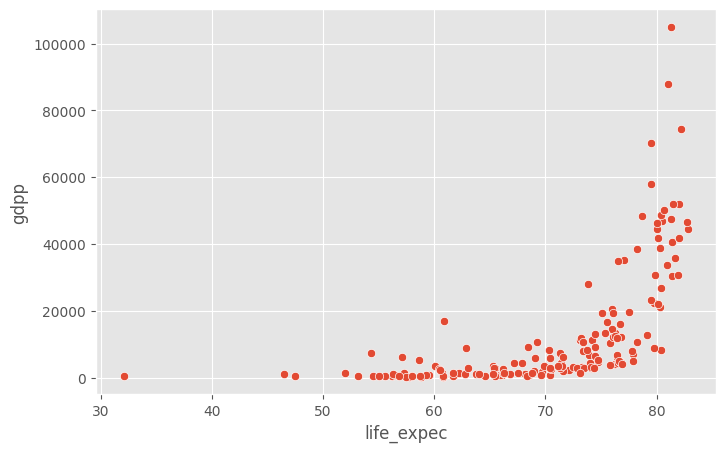

In [128]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="life_expec",y="gdpp")
plt.show()

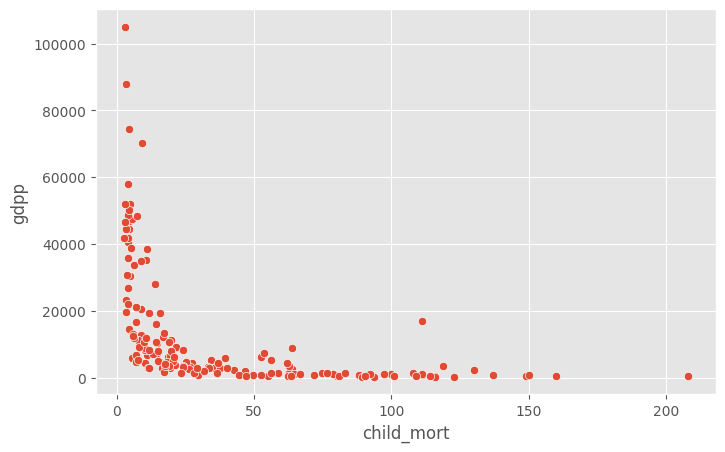

In [129]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="child_mort",y="gdpp")
plt.show()

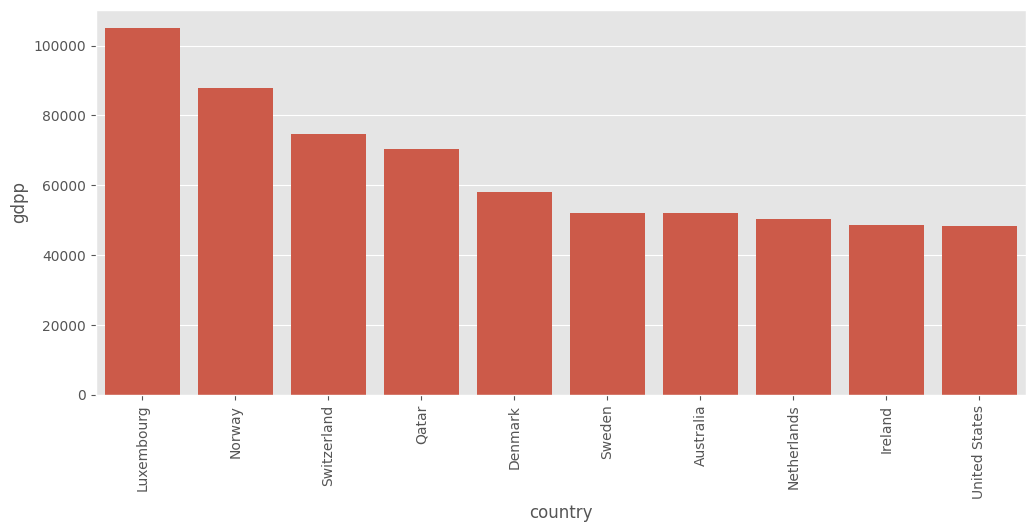

In [130]:
top=df.sort_values("gdpp",ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(data=top,x="country",y="gdpp")
plt.xticks(rotation=90)
plt.show()

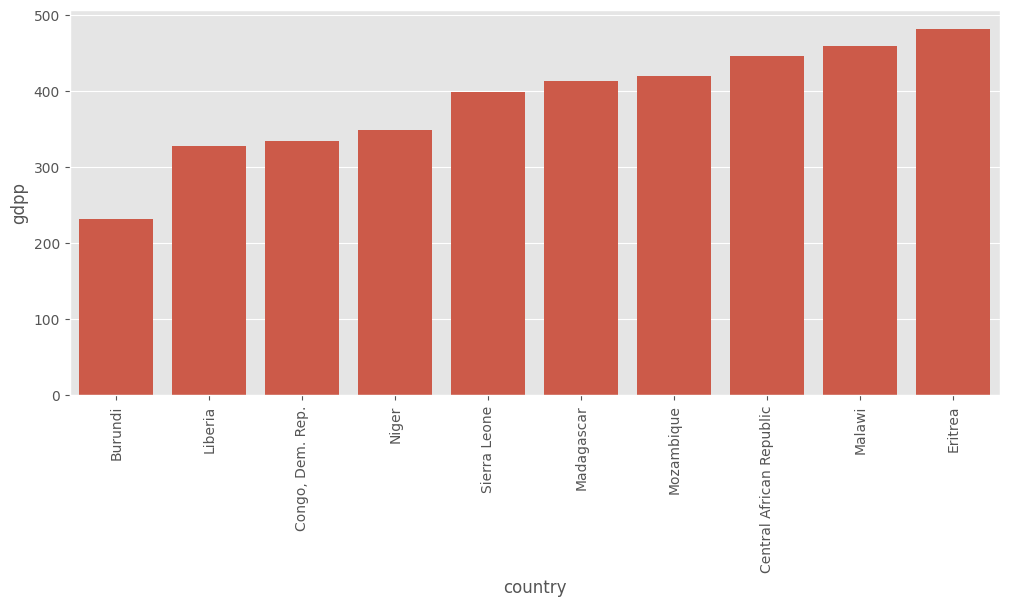

In [131]:
bottom=df.sort_values("gdpp").head(10)

plt.figure(figsize=(12,5))
sns.barplot(data=bottom,x="country",y="gdpp")
plt.xticks(rotation=90)
plt.show()

<Figure size 1000x600 with 0 Axes>

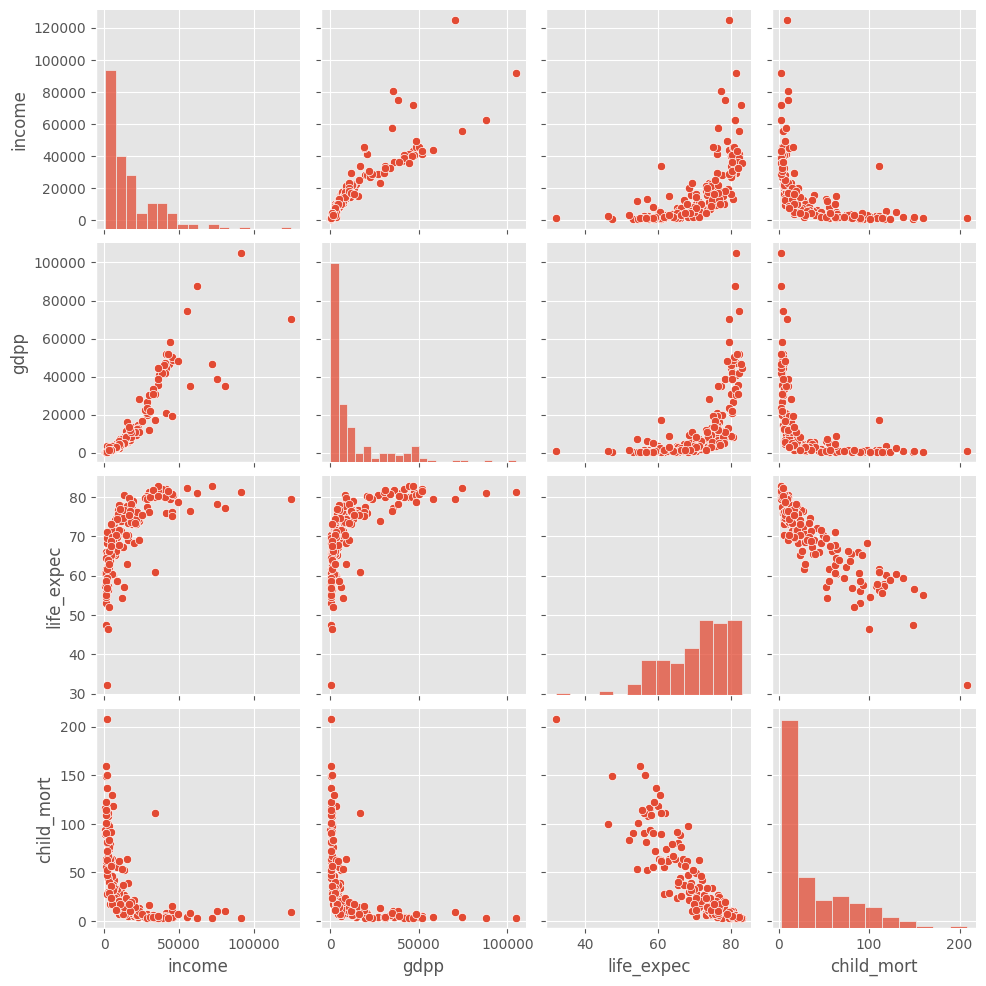

In [132]:
plt.figure(figsize=(10,6))
sns.pairplot(df[["income","gdpp","life_expec","child_mort"]])
plt.show()

In [133]:
df["Country_Code"]=LabelEncoder().fit_transform(df["country"])

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Country_Code
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,3
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,4


In [134]:
df["Development_Level"]=pd.qcut(
    df["gdpp"],
    q=3,
    labels=[0,1,2]
)

df["Development_Level"]=df["Development_Level"].astype(int)

df[["country","gdpp","Development_Level"]].head()

,country,gdpp,Development_Level
0,Afghanistan,553,0
1,Albania,4090,1
2,Algeria,4460,1
3,Angola,3530,1
4,Antigua and Barbuda,12200,2


In [135]:
X = df.drop(columns=["country","Development_Level"])
y = df["Development_Level"]

print(X.shape)
print(y.shape)

(167, 10)
(167,)


In [136]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Country_Code
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180,-1.721710
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623,-1.700967
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376,-1.680223
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268,-1.659480
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817,-1.638736


In [137]:
X_train,X_test,y_train,y_test=train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(133, 10)
(34, 10)


In [138]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

In [139]:
print("Decision Tree Accuracy")

print(accuracy_score(y_test,dt_pred))

Decision Tree Accuracy
0.9411764705882353


In [140]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.91      0.91      0.91        11
           2       0.92      1.00      0.96        11

    accuracy                           0.94        34
   macro avg       0.94      0.94      0.94        34
weighted avg       0.94      0.94      0.94        34



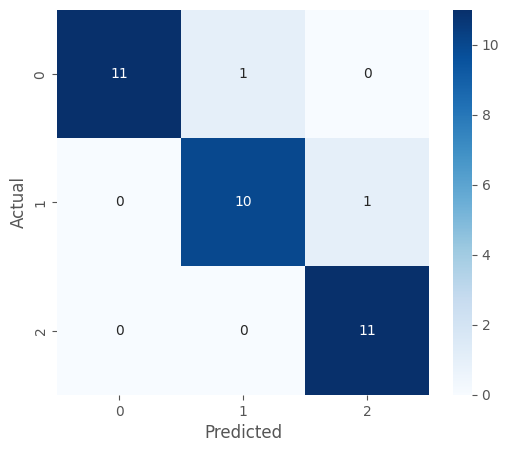

In [141]:
cm = confusion_matrix(y_test,dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [142]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [143]:
print("Random Forest Accuracy")

print(accuracy_score(y_test,rf_pred))

Random Forest Accuracy
0.9411764705882353


In [144]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.91      0.91      0.91        11
           2       0.92      1.00      0.96        11

    accuracy                           0.94        34
   macro avg       0.94      0.94      0.94        34
weighted avg       0.94      0.94      0.94        34



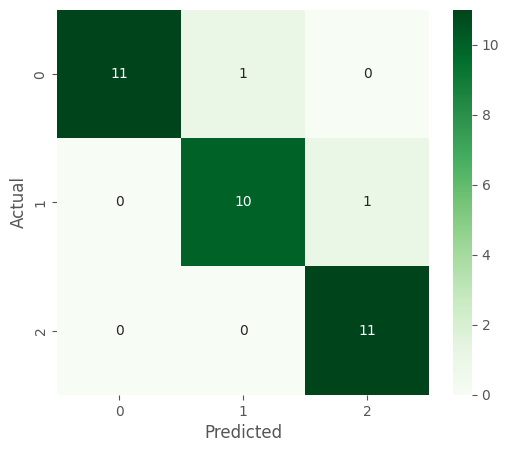

In [145]:
cm = confusion_matrix(y_test,rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Greens")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [146]:
xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

In [147]:
print("XGBoost Accuracy")

print(accuracy_score(y_test,xgb_pred))

XGBoost Accuracy
1.0


In [148]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        11

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



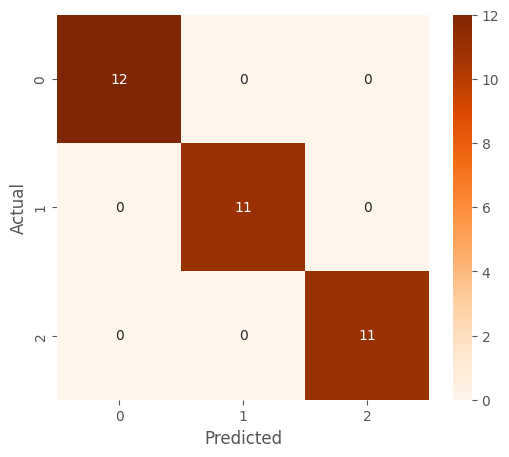

In [149]:
cm = confusion_matrix(y_test,xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Oranges")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [150]:
results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred)
    ]

})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,XGBoost,1.000000
0,Decision Tree,0.941176
1,Random Forest,0.941176


In [151]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
8,gdpp,0.434880
4,income,0.232601
0,child_mort,0.126735
6,life_expec,0.076297
7,total_fer,0.046144
1,exports,0.025055
5,inflation,0.023308
2,health,0.014434
9,Country_Code,0.011768
3,imports,0.008779


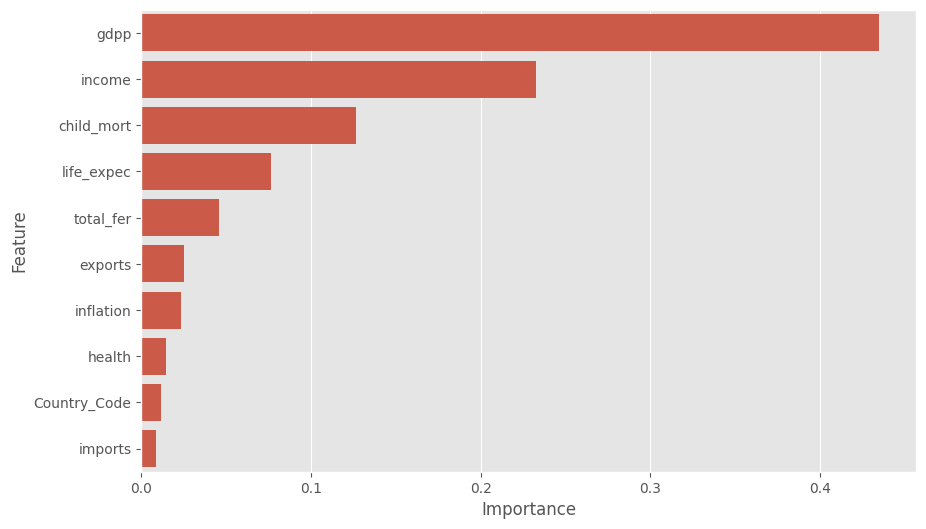

In [152]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.show()

In [153]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5]

}

In [154]:
grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [155]:
print(grid.best_params_)

print(grid.best_score_)

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
0.97008547008547


In [156]:
best_rf = grid.best_estimator_

best_pred = best_rf.predict(X_test)

In [157]:
print("Optimized Random Forest")

print(accuracy_score(y_test,best_pred))

print(classification_report(y_test,best_pred))

Optimized Random Forest
0.9117647058823529
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.83      0.91      0.87        11
           2       0.91      0.91      0.91        11

    accuracy                           0.91        34
   macro avg       0.91      0.91      0.91        34
weighted avg       0.92      0.91      0.91        34



In [158]:
joblib.dump(best_rf,"best_customer_classifier.pkl")

print("Model Saved")

Model Saved


In [159]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Optimized RF"
    ],

    "Accuracy":[
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred),
        accuracy_score(y_test,best_pred)
    ]

})

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,XGBoost,1.000000
0,Decision Tree,0.941176
1,Random Forest,0.941176
3,Optimized RF,0.911765


In [160]:
features = X_scaled.copy()

features.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Country_Code
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180,-1.721710
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623,-1.700967
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376,-1.680223
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268,-1.659480
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817,-1.638736


In [161]:
wcss = []

for i in range(2,11):
    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    km.fit(features)
    wcss.append(km.inertia_)

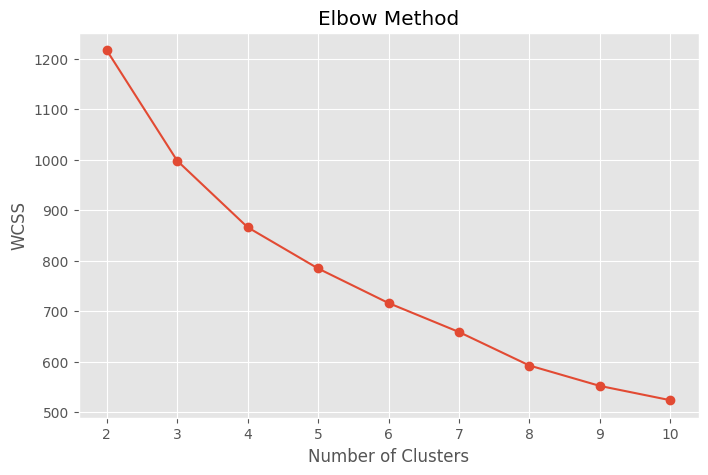

In [162]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11),wcss,marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [163]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(features)

df["KMeans_Cluster"] = kmeans_labels

In [164]:
print(df["KMeans_Cluster"].value_counts())

KMeans_Cluster
2    85
1    47
0    35
Name: count, dtype: int64


In [165]:
score = silhouette_score(features,kmeans_labels)

print(score)

0.24043690533753959


In [166]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(features)

pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1","PC2"]
)

pca_df.head()

,PC1,PC2
0,-2.958742,-0.069228
1,0.382716,-0.764844
2,-0.330796,-0.608983
3,-2.975090,1.548361
4,0.988175,-0.040027


In [167]:
pca_df["Cluster"] = kmeans_labels

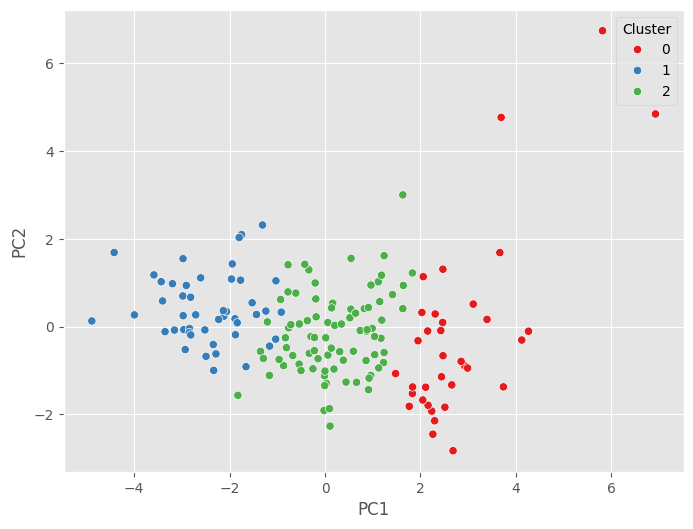

In [168]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.show()

In [169]:
dbscan = DBSCAN(
    eps=1.3,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(features)

df["DBSCAN_Cluster"] = dbscan_labels

In [170]:
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
-1    98
 0    54
 1    15
Name: count, dtype: int64


In [171]:
pca_df["DBSCAN"] = dbscan_labels

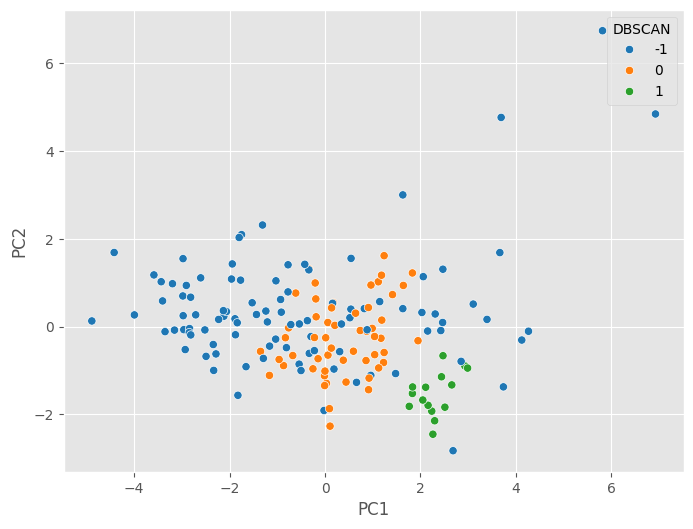

In [172]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN",
    palette="tab10"
)

plt.show()

In [173]:
cluster_summary = df.groupby("KMeans_Cluster").mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Country_Code,Development_Level,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,
0,4.897143,58.431429,8.917429,51.508571,45802.857143,2.535000,80.245714,1.741143,43117.142857,88.457143,2.000000,-0.114286
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,81.361702,0.191489,-1.000000
2,21.770588,40.588106,6.186471,47.513716,12644.352941,7.599012,72.851765,2.305765,6653.670588,81.658824,1.035294,-0.376471


In [174]:
cluster_summary.T

KMeans_Cluster,0,1,2
child_mort,4.897143,92.961702,21.770588
exports,58.431429,29.151277,40.588106
health,8.917429,6.388511,6.186471
imports,51.508571,42.323404,47.513716
income,45802.857143,3942.404255,12644.352941
inflation,2.535000,12.019681,7.599012
life_expec,80.245714,59.187234,72.851765
total_fer,1.741143,5.008085,2.305765
gdpp,43117.142857,1922.382979,6653.670588
Country_Code,88.457143,81.361702,81.658824


In [175]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
8,gdpp,0.428028
4,income,0.240667
0,child_mort,0.133133
6,life_expec,0.074762
7,total_fer,0.041779
1,exports,0.024314
5,inflation,0.023249
2,health,0.012623
9,Country_Code,0.012066
3,imports,0.009381


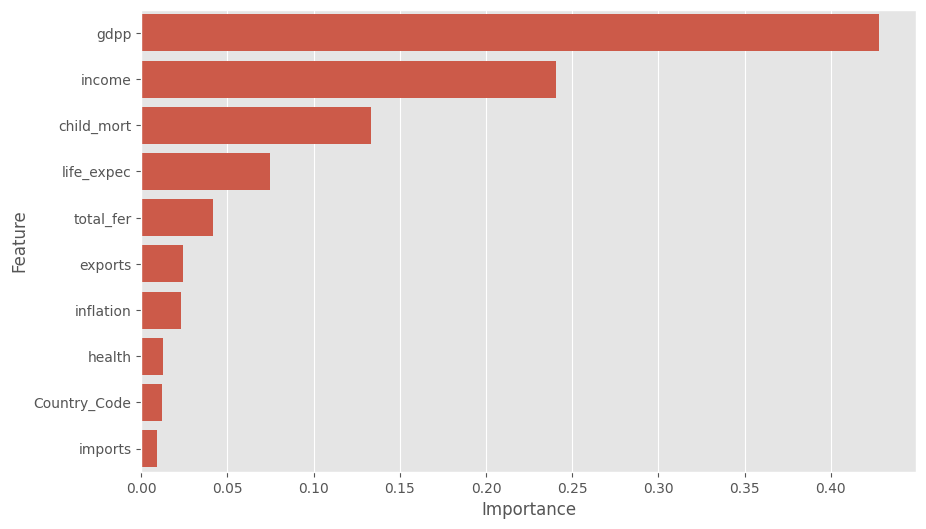

In [176]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.show()

In [177]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Country_Code,Development_Level,KMeans_Cluster,DBSCAN_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0,0,1,-1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1,1,2,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,1,2,-1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,3,1,1,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,4,2,2,0


In [178]:
df.groupby("KMeans_Cluster")["gdpp"].mean()

,gdpp
KMeans_Cluster,
0,43117.142857
1,1922.382979
2,6653.670588


In [179]:
df.groupby("KMeans_Cluster")["income"].mean()

,income
KMeans_Cluster,
0,45802.857143
1,3942.404255
2,12644.352941


In [180]:
df.groupby("KMeans_Cluster")["life_expec"].mean()

,life_expec
KMeans_Cluster,
0,80.245714
1,59.187234
2,72.851765


In [181]:
df.groupby("KMeans_Cluster")["child_mort"].mean()

,child_mort
KMeans_Cluster,
0,4.897143
1,92.961702
2,21.770588


In [182]:
joblib.dump(kmeans,"kmeans_customer_segmentation.pkl")

joblib.dump(scaler,"scaler.pkl")

print("Models Saved Successfully")

Models Saved Successfully


In [187]:
from google.colab import files

files.download("best_customer_classifier.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [188]:
files.download("kmeans_customer_segmentation.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>